In [121]:
##importar las librerias a usar
import pandas as pd
import matplotlib.pyplot as plt



In [122]:
#leer el file de adjust con el comportamiento de drop offs.
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("2026-3-18_15_42_adjust_report_export.csv")

Saving 2026-3-18_15_42_adjust_report_export.csv to 2026-3-18_15_42_adjust_report_export (5).csv


In [123]:
## ver por encima los datos
df.head(5)

,campaign_network,day,journey drop off_m0_conversions_per_period,journey drop off_m1_conversions_per_period,journey drop off_m2_conversions_per_period
0,AR-ALL-RIDER-ACQ-INST-SOCIAL-VIDEO-AND-CPM-AON...,2025-10-01,470,167,106
1,AR-ALL-RIDER-ACQ-INST-SOCIAL-VIDEO-AND-CPM-AON...,2025-10-01,1,0,0
2,AR-ALL-RIDER-ACQ-INST-SOCIAL-VIDEO-AND-CPM-AON...,2025-10-01,4,1,0
3,AR-BRC-RIDER-ACQ-INST-SEARCH-UAC-AND-CPC-ALWAY...,2025-10-01,5,1,1
4,AR-BUE-CORP-ACQ-LEAD-SEARCH-DISP-DM-CPA-ALWAYS...,2025-10-01,2,2,2


In [124]:
##sacamos la columna M2 ya que estamos viendo los ultimos 2 meses
df = df.drop(columns=['journey drop off_m2_conversions_per_period'])

In [130]:
## lo vamos a cambiar nombres de las columnas
df = df.rename(columns={
    'campaign_network': 'campaign',
    'day': 'date',
    'journey drop off_m0_conversions_per_period': 'drop_off_0m',
    'journey drop off_m1_conversions_per_period': 'drop_off_1m',
    })

In [131]:
df.head()

,campaign,date,drop_off_0m,drop_off_1m
0,AR-ALL-RIDER-ACQ-INST-SOCIAL-VIDEO-AND-CPM-AON...,2025-10-01,470,167
1,AR-ALL-RIDER-ACQ-INST-SOCIAL-VIDEO-AND-CPM-AON...,2025-10-01,1,0
2,AR-ALL-RIDER-ACQ-INST-SOCIAL-VIDEO-AND-CPM-AON...,2025-10-01,4,1
3,AR-BRC-RIDER-ACQ-INST-SEARCH-UAC-AND-CPC-ALWAY...,2025-10-01,5,1
4,AR-BUE-CORP-ACQ-LEAD-SEARCH-DISP-DM-CPA-ALWAYS...,2025-10-01,2,2


In [138]:
## tranformar la columna date a fecha real
df['date'] = pd.to_datetime(df['date'])

In [139]:
## ver los nombres como quedaron
print(df.columns)

Index(['campaign', 'date', 'drop_off_0m', 'drop_off_1m'], dtype='object')


In [140]:
## vmaos a pasar de dias a verlo por semana ya que los viajes se hacen aprox cada 5 dias (se agrupa cada dia por semana y se suma)
weekly = df.groupby(pd.Grouper(key='date', freq='W')).agg({
    'drop_off_0m': 'sum',
    'drop_off_1m': 'sum',
}).reset_index()

In [142]:
## ahora calculamos el nivel de retención a lo largo del tiempo (tasa de caida de viajes)
weekly['retention_1m'] = weekly['drop_off_1m'] / weekly['drop_off_0m']


print(weekly.columns)

Index(['date', 'drop_off_0m', 'drop_off_1m', 'retention_1m'], dtype='object')


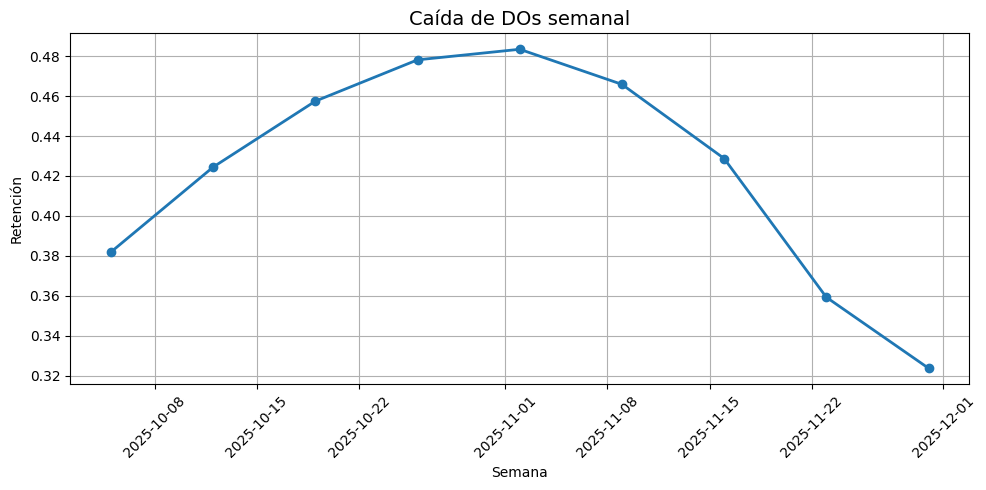

In [151]:
#hacer un grafico por semana que se vea la tasa de retención

plt.figure(figsize=(10,5))

plt.plot(weekly['date'], weekly['retention_1m'], marker='o', linewidth=2)

plt.title("Caída de DOs semanal", fontsize=14)
plt.xlabel("Semana")
plt.ylabel("Retención")

plt.xticks(rotation=45)

plt.grid()

plt.tight_layout()

plt.show()

In [152]:
### para hacerlo mas presentable para el cliente vamos a cambiar las fechas de las semanas por el numero de semana
weekly = weekly.sort_values('date').reset_index(drop=True)

# crear etiquetas W1, W2, W3...
weekly['week_label'] = ['W' + str(i+1) for i in range(len(weekly))]

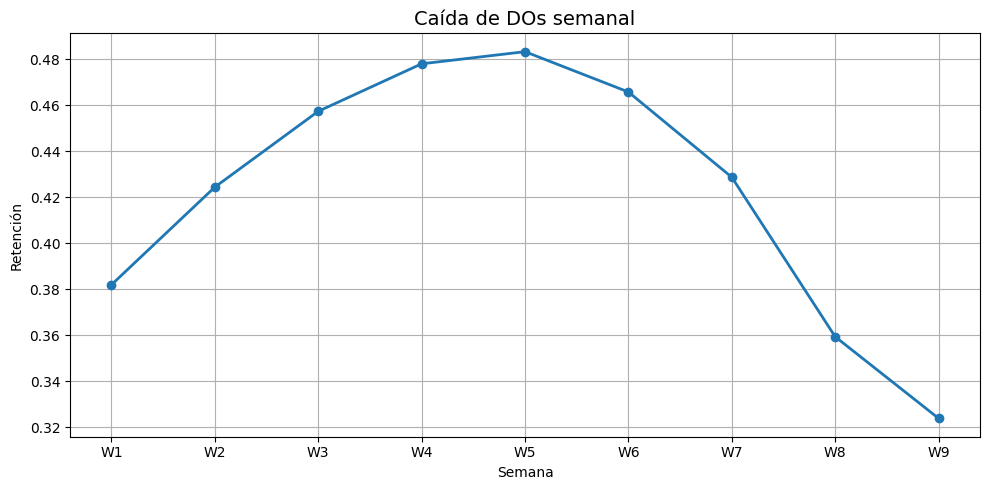

In [153]:
#lo graficamos de nuevo

plt.figure(figsize=(10,5))

plt.plot(weekly['week_label'], weekly['retention_1m'], marker='o', linewidth=2)

plt.title("Caída de DOs semanal", fontsize=14)
plt.xlabel("Semana")
plt.ylabel("Retención")

plt.grid()
plt.tight_layout()

plt.show()

In [ ]:
# vemos que en la seman 8 tuvimos una caida de churn